In [8]:
from typing import List, Dict

import os
import re
import glob
import json
import collections

import csv

In [34]:
def clean_probe_config(probe_config: Dict[str, str]) -> Dict[str, str]:
    host = probe_config['host']
    host = re.match(r'(\d+\.\d+\.\d+\.\d+|[aA]ll).*', host).group(1)

    return { **probe_config, "host": host }

In [35]:
def build_scenario(exp_conf: List[Dict[str, str]]) -> Dict[str, List[str]]:
    '''
    starting from the list of { host: x.x.x.x, probe: probe-name }
    returns a dictionary where
        - key: target (ip address)
        - value: set of recommended probes. set is used 
    '''

    result = collections.defaultdict(set)
    for probe_info in exp_conf:
        probe_info = clean_probe_config(probe_info)
        result[probe_info['host'].lower()].add(probe_info['probe'].lower())

    return result

In [40]:
with open('../data/100-m-m.csv', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    next(reader)
    ground_truth = [build_scenario(json.loads(x[1])) for x in reader]

exp_files = glob.glob('../data/selection_results/json_*')
exps_results = {}
for exp_file in exp_files:
    print(f'processing {exp_file}')
    with open(exp_file, 'r') as f:
        exp_results = json.loads(f.read())
        exp_results = [build_scenario(scenario['conf']) for scenario in exp_results]
        exps_results[exp_file] = exp_results

processing ../data/selection_results/json_100-m-m_prompt_5c_results.json
processing ../data/selection_results/json_100-m-m_prompt_5_results.json
processing ../data/selection_results/json_100-m-m_prompt_2_results.json
processing ../data/selection_results/json_100-m-m_prompt_3_results.json
processing ../data/selection_results/json_100-m-m_prompt_4_results.json


## Compare groundtruth with LLM-generated recommendation

In [49]:
exps_metrics = {}

for exp_name, exp_results in exps_results.items():
    exps_metrics[exp_name] = []
    for exp_scenario, gt_scenario in zip(exp_results, ground_truth):
        # detected probes are the intersection between expert recommended probes and LLM recommended probes
        scenario_detected_probes = 0
        # missing probes are the set-difference between the expert recommended probes and LLM recommended probes
        scenario_missing_probes = 0
        # redundant probes are those that the LLM recommends but are not relevant: the potential causes could be
        # incorrect probe, wrong target 
        scenario_redundant_probes = 0
        for host in gt_scenario:
            gt_probes = gt_scenario[host]
            exp_probes = exp_scenario.get(host, set())
        
            host_detected_probes = gt_probes & exp_probes
            scenario_detected_probes += len(host_detected_probes)
            host_missing_probes = gt_probes - exp_probes
            scenario_missing_probes += len(host_missing_probes)
            host_redundant_probes = exp_probes - gt_probes
            scenario_redundant_probes += len(host_redundant_probes)
            
            # print(f'host {host}: {host_detected_probes}/{host_missing_probes}/{host_redundant_probes}')
    
        # print(f'{scenario_detected_probes}/{scenario_missing_probes}/{scenario_redundant_probes}')
        exps_metrics[exp_name].append((scenario_detected_probes, scenario_missing_probes, scenario_redundant_probes))

/tmp/ipykernel_33570/441183768.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


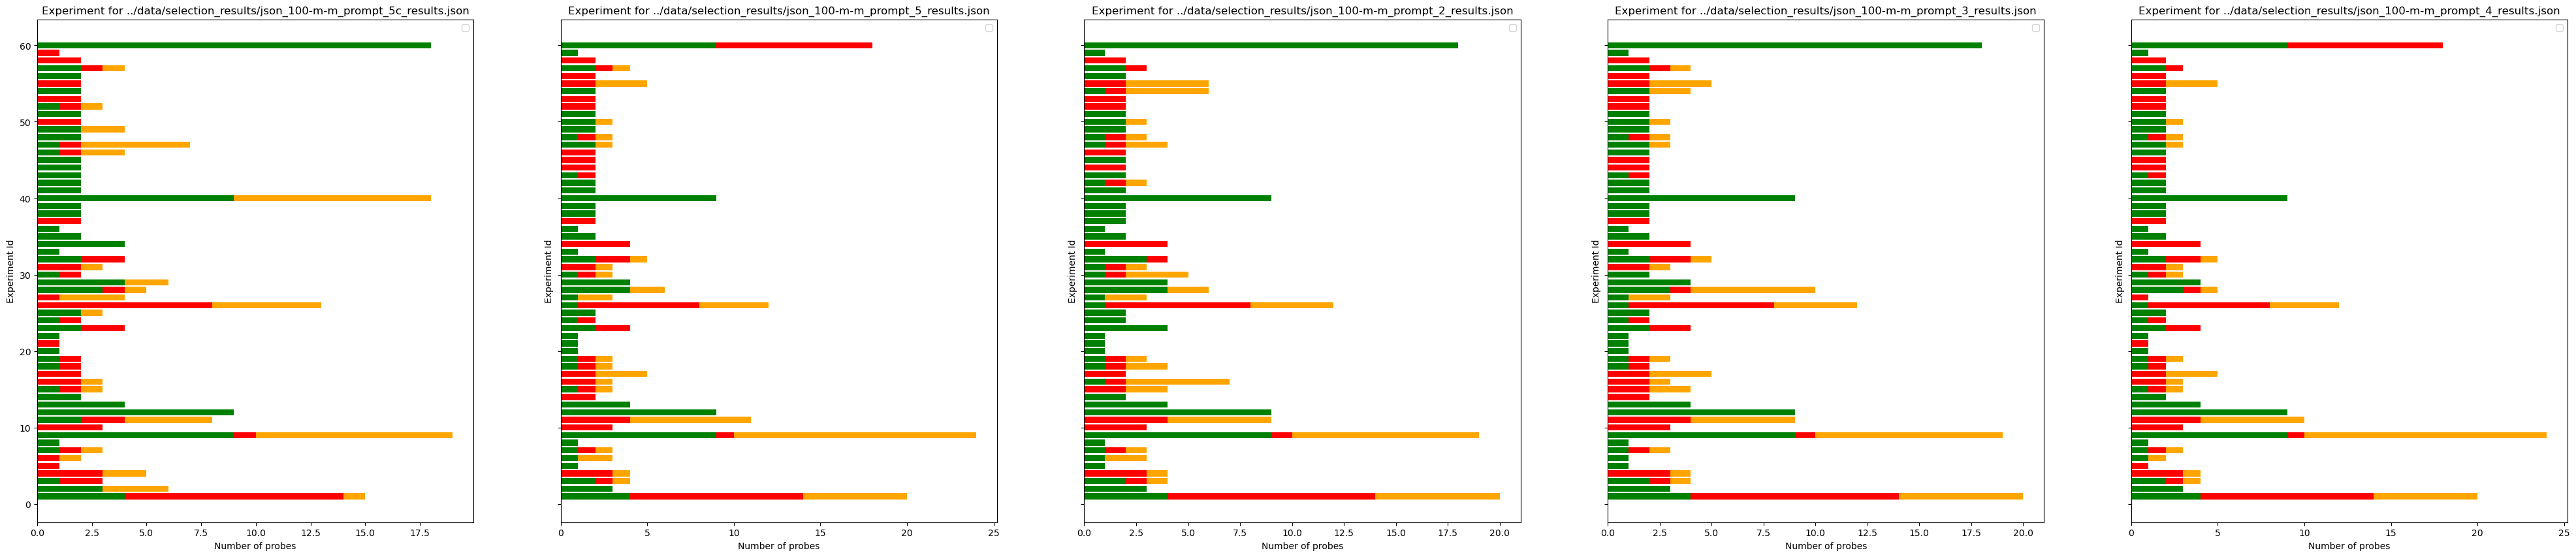

In [56]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1, len(exps_metrics), sharey=True, figsize=(50, 10))

for i_exp, (exp_name, exp_metrics) in enumerate(exps_metrics.items()):
    ax = axs[i_exp]
    ax.set_xlabel("Number of probes")
    ax.set_ylabel("Experiment Id")
    ax.set_title(f"Experiment for {exp_name}")    
    ax.legend()

    y_values = list(range(1, 61))
    detected = np.array([x[0] for x in exp_metrics])
    ax.barh(y_values, detected, color='green')
    
    missing = np.array([x[1] for x in exp_metrics])
    ax.barh(y_values, missing, left=detected, color='red')
    
    redundant = np.array([x[2] for x in exp_metrics])
    ax.barh(y_values, redundant, left=detected+missing, color='orange')


# plt.tight_layout()
plt.show()

fig.savefig('../data/exp_results.png')